# Unsupervised Learning

*Unless specified, all figures in this document are taken from: Aurélien Géron. Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow. Third Edition. O’Reilly, 2022. ISBN: 978-1-098-12597-4.*

Unlike supervised learning, where the algorithm is provided with labeled data (input-output pairs) to learn from unsupervised learning is a type of machine learning technique where the model is trained on a dataset **without** any supervision or **labeled responses**. The main goal of unsupervised learning is to explore the structure of the data, **discover hidden patterns**, and extract meaningful insights. Common tasks in unsupervised learning include **clustering**, **dimensionality reduction**, and **anomaly detection**.

# Clustering Algorithms

A **clustering** algorithm is a type of **unsupervised** machine learning algorithm that aims to **partition** a dataset into **groups or clusters** of similar data points. The **goal** is to group data points **together based on their similarities**, with the assumption that data points within the same cluster are more similar to each other compared to those in different clusters.

The diagram on the **left** displays the iris dataset, where each instance's species (or class) is denoted by a distinct marker, indicating a **classification problem**. Conversely, the diagram on the **right** depicts the identical dataset but without the labels, so we cannot use a classification algorithm anymore. This is where clustering algorithms come into play. Clustering algorithms **effectively leverage all features** to discern the **three clusters** quite accurately, with minimal instances misallocated to the wrong cluster.

<br />
<div>
<img src=attachment:image.png width = 700>
</div>

<p style="text-align: center;"> <strong> Classification (left) versus clustering (right) </strong> </p>

Clustering algorithms are widely used in various real-world applications across different domains. Some of the common applications include:

* **Customer Segmentation**: Businesses use clustering algorithms to segment their customer base based on purchasing behavior, demographics, or other relevant features. This helps in targeted marketing strategies and personalized customer experiences.


* **Document Clustering**: In natural language processing (NLP), clustering algorithms are used to group similar documents together. This is helpful in tasks such as document organization, topic modeling, and information retrieval.


* **Image Segmentation**: Clustering algorithms are used in computer vision to segment images into meaningful regions or objects. This is useful in tasks such as image recognition, object detection, and medical image analysis.


* **Recommendation Systems**: Clustering algorithms can be used to group similar items or users together in recommendation systems. This helps in making personalized recommendations to users based on their preferences or behavior.


* **Genomic Data Analysis**: In bioinformatics, clustering algorithms are used to analyze genomic data and identify patterns or clusters of genes with similar expression profiles. This is important for understanding gene functions and disease mechanisms.


* **Anomaly Detection**: Clustering algorithms can be used for anomaly detection by identifying data points that do not belong to any of the clusters. This is useful in detecting fraudulent activities, network intrusions, or manufacturing defects.


* **Social Network Analysis**: Clustering algorithms are used to analyze social networks and identify communities or groups of individuals with similar interests or connections. This helps in understanding social structures and influence patterns.


* **Market Basket Analysis**: Clustering algorithms are used in retail for market basket analysis, where they identify groups of products that are frequently purchased together. This information is used for product placement, cross-selling, and upselling strategies.


* **Climate Data Analysis**: Clustering algorithms are used in meteorology and climatology to analyze climate data and identify weather patterns or climatic zones. This helps in understanding climate variability and predicting extreme weather events.


* **Fraud Detection**: Clustering algorithms can be used in finance and banking for fraud detection by identifying clusters of transactions with suspicious patterns or behaviors.


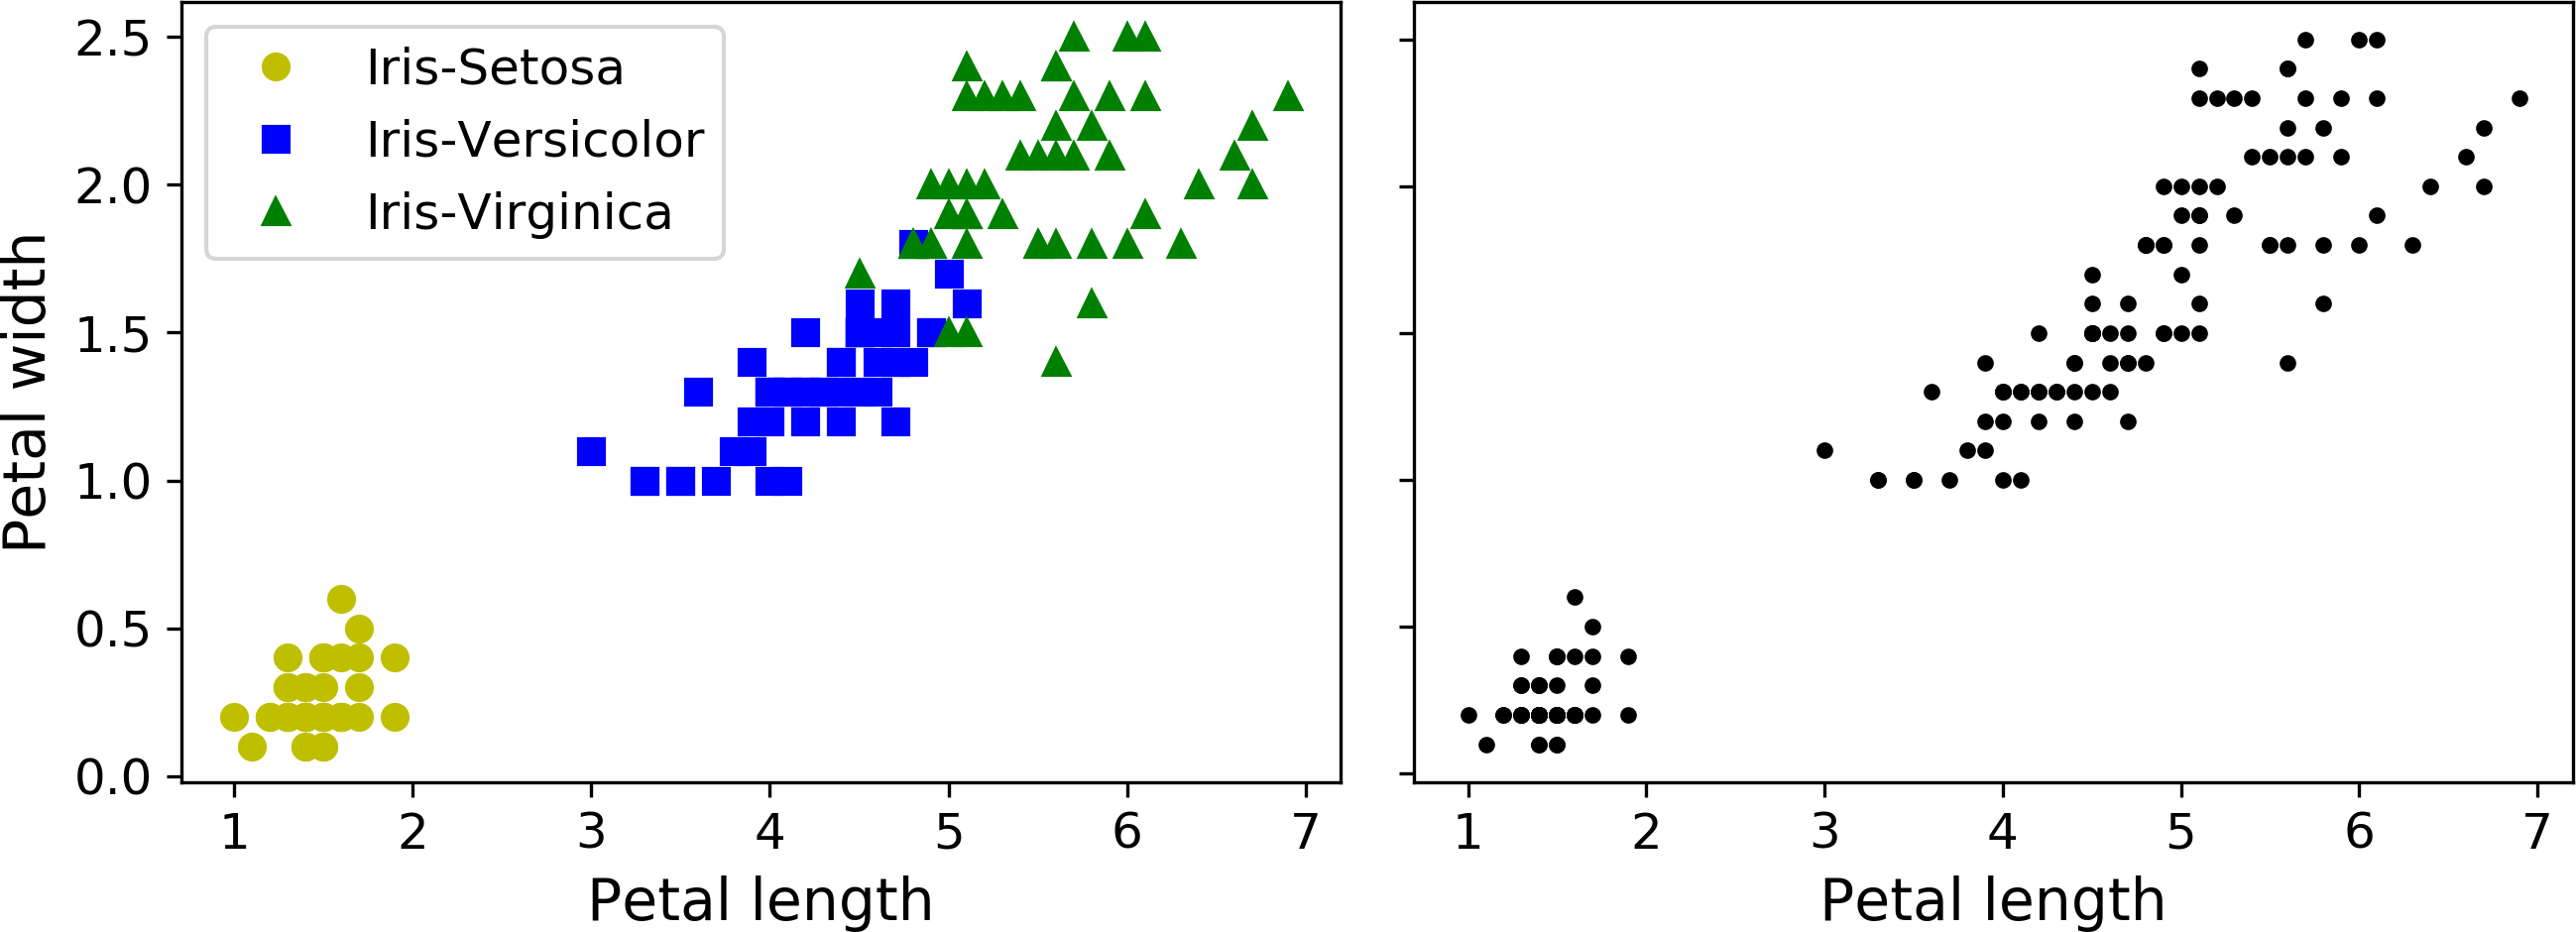

## K-means Clustering

K-means clustering is simple unsupervised machine learning algorithm for **partitioning** a dataset into a **predefined number of clusters**. It works by **iteratively assigning data points to clusters** and **updating cluster centroids** until convergence is reached. Here's how the algorithm works:

1. **Initialization**: The algorithm starts by **randomly selecting K data points** from the dataset to serve as the initial cluster centroids. These centroids can also be initialized using other methods like **K-means++** to improve convergence speed and cluster quality. The default method of initialization in the `scikit-learn` library is `k-means++`.


2. **Assignment**: Each data point in the dataset is assigned to the nearest centroid, forming K clusters. The distance between data points and centroids is typically measured using **Euclidean distance**, but other distance metrics can also be used.


3. **Update**: After assigning data points to clusters, the centroids are recalculated by taking the mean of all data points assigned to each cluster. These new centroids represent the "centers" of the clusters.


4. **Iteration**: Steps 2 and 3 are repeated iteratively until **convergence is reached**. Convergence occurs when the **centroids no longer change** significantly between iterations or when a **maximum number of iterations is reached**.

<br />
<div>
<img src=attachment:image.png width = 500>
</div>
<p style="text-align: center;"> <strong> An unlabeled dataset composed of five blobs of instances </strong> </p>

Consider a sample unlabeled dataset containing five blobs (see above). The centroids are initialized randomly (top left), then the instances are labeled (top right), then the centroids are updated (center left), the instances are relabeled (center right), and so on. As you can see, in just 3 iterations the K-means algorithm has reached a clustering that seems close to optimal.  
<br />
<div>
<img src=attachment:image-3.png width = 1000>
</div>
<p style="text-align: center;"> <strong> A sample run of the K-Means algorithm on the dataset containing five blobs</strong> </p>

**Clustering Algorithm Performance Metrics**

Measuring the quality of a clustering solution is crucial for assessing how well the algorithm has grouped the data points into meaningful clusters. Several metrics can be used to evaluate the quality of clustering solutions. Here are the two most commonly used metrics to evaluate the performance of clustering algorithms:

* **Silhouette Score**: The silhouette score measures how similar an object is to its own cluster compared to other clusters. It ranges from **-1 to 1**, where a **high value** indicates dense and well-separated clusters. Higher silhouette scores suggest better clustering solutions.

    $S = \frac{1}{N} \sum_{i=1}^{N} s(i)$

    Where $N$ is the total number of data points. $s(i)$ is the silhouette coefficient for the $i$-th data point, calculated as:

     $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$   

    Where $a(i)$ is the average distance from the $i$-th data point to other data points within the same cluster (i.e., the mean intra-cluster distance), and $b(i)$ is the minimum average distance from the $i$-th data point to data points in a different cluster (the mean inter-cluster distance).

<br />
<div>
<img src=attachment:image-6.png width = 600>
</div>
<p style="text-align: center;"> <strong> Clustering example with intra-and-inter-clustering distances</strong> </p>
   
*Image source: https://www.researchgate.net/figure/Clustering-example-with-intra-and-inter-clustering-illustrations_fig1_344590665*
   
* **Davies-Bouldin Index**: The Davies-Bouldin index measures the **average similarity between each cluster** and **its most similar cluster**, relative to the **size of the clusters**. **Lower** Davies-Bouldin index values indicate better clustering solutions. 
    
    $DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} \left( \frac{S_i + S_j}{d(c_i, c_j)} \right)$
 
    Where, $K$ is the number of clusters, $S_i$ is the scatter (intra-cluster distance) of cluster $i$, $c_i$ is the centroid of cluster $i$, and $d(c_i,c_j)$ is the distance between centroids of clusters $i$ and $j$.

**Interpreting DBI Values**

There is no universal threshold because the value depends on the dataset and dimensionality. However, a common interpretation is:

| DBI       | Interpretation       |
| --------- | -------------------- |
| < 0.5     | Very good clustering |
| 0.5 – 1.0 | Good clustering      |
| 1.0 – 2.0 | Moderate clustering  |
| > 2.0     | Poor clustering      |

    
**Optimal Number of Clusters (K = ?)**

In the given example, we have arbitrarily set the number of clusters $K$ to 5 based on prior knowledge or visual inspection of the data. However, in most cases, determining the appropriate value for $K$ is not straightforward, and selecting an incorrect value can lead to **suboptimal clustering results**. Therefore, it's essential to employ techniques such as the elbow method, **silhouette score** or other methods to objectively determine the **optimal number of clusters** for a given dataset. Failure to do so may result in poor clustering performance.

<br />
<div>
<img src=attachment:image-4.png width = 600>
</div>
<p style="text-align: center;"> <strong> Selecting the number of clusters k using the silhouette score</strong> </p>

From the above graph depicting silhouette scores for $K$ ranging from 2 to 8, it's evident that the optimal number of clusters for our example is $K$=4. Moreover, we can also see that the silhouette score when $K$=5 is comparable to the optimal cluster size, $K$=4. and much better than $K$=6. A more informative visualization is achieved by plotting the silhouette coefficient of each instance, organized by their assigned cluster and sorted by the coefficient's value. This visualization, known as a **silhouette diagram**, provides a comprehensive view of the clustering quality. The vertical dashed lines illustrate the silhouette score corresponding to each number of clusters. When a cluster's majority of instances exhibit a silhouette coefficient lower than this score, then, it signifies **poor clustering** since this means its instances are **much too close to other clusters**.

<br />
<div>
<img src=attachment:image-5.png width = 600>
</div>
<p style="text-align: center;"> <strong> Silouhette analysis: comparing the silhouette diagrams for various values of
$K$</strong> </p>
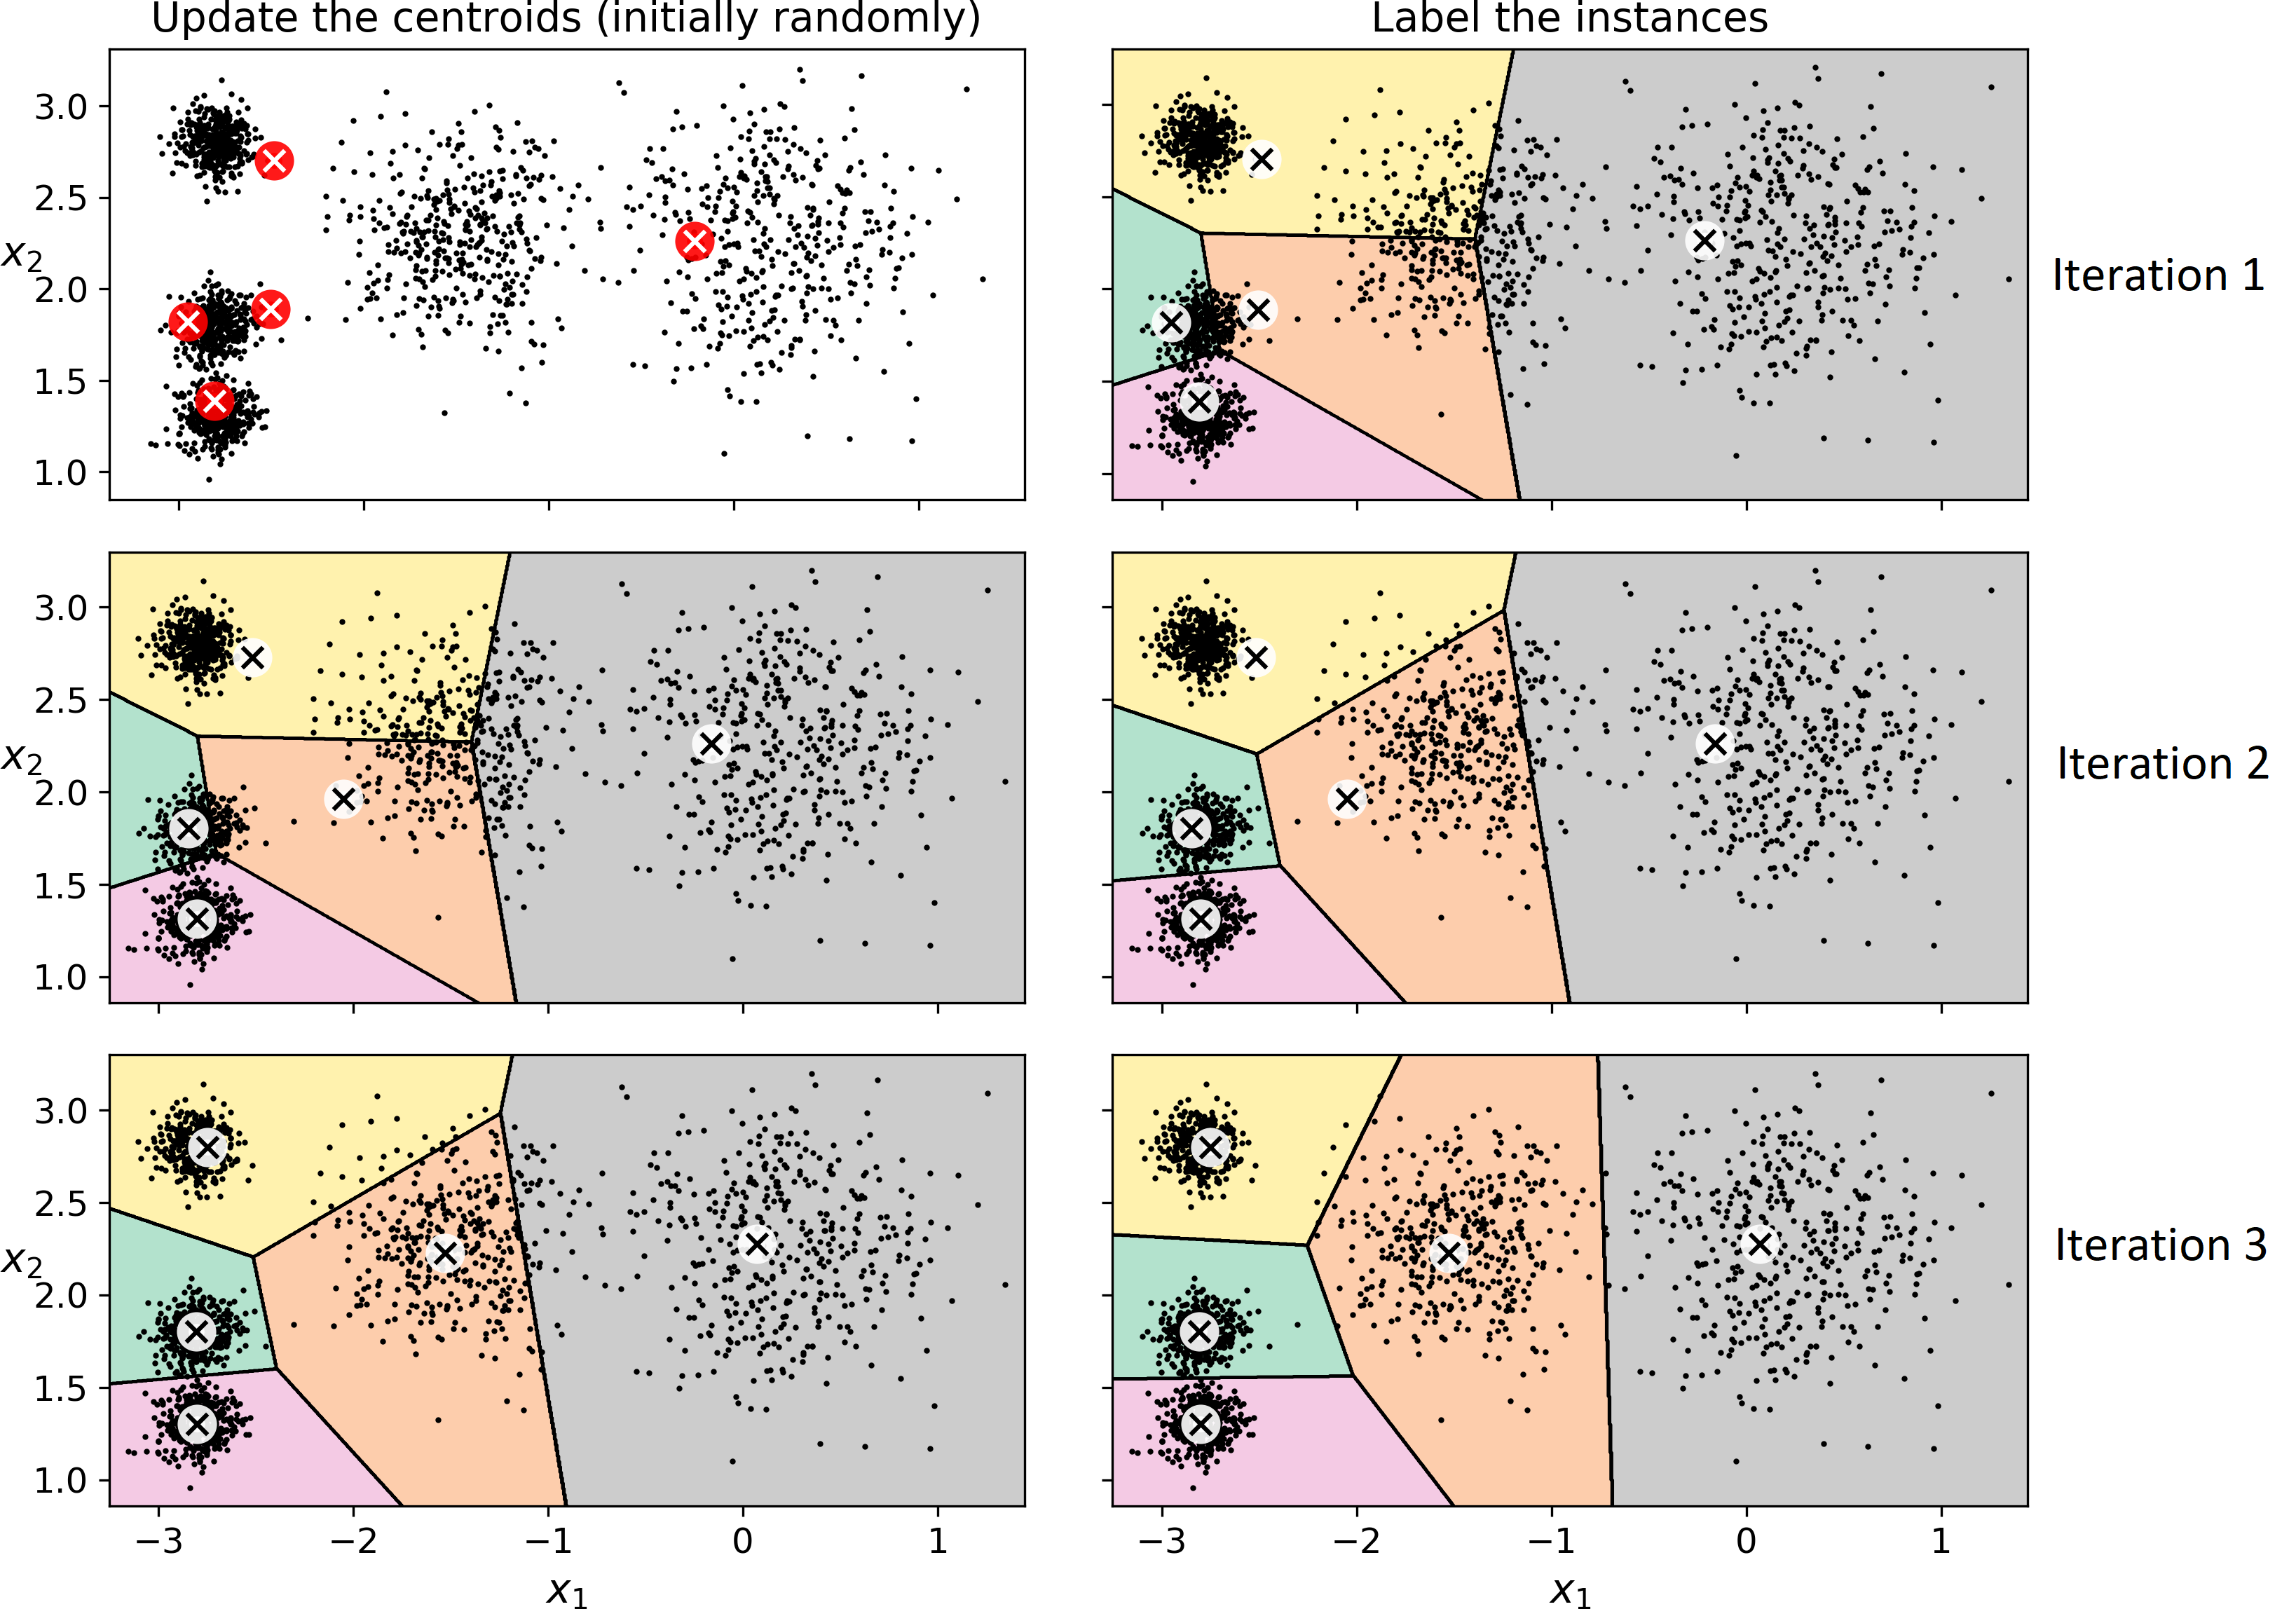
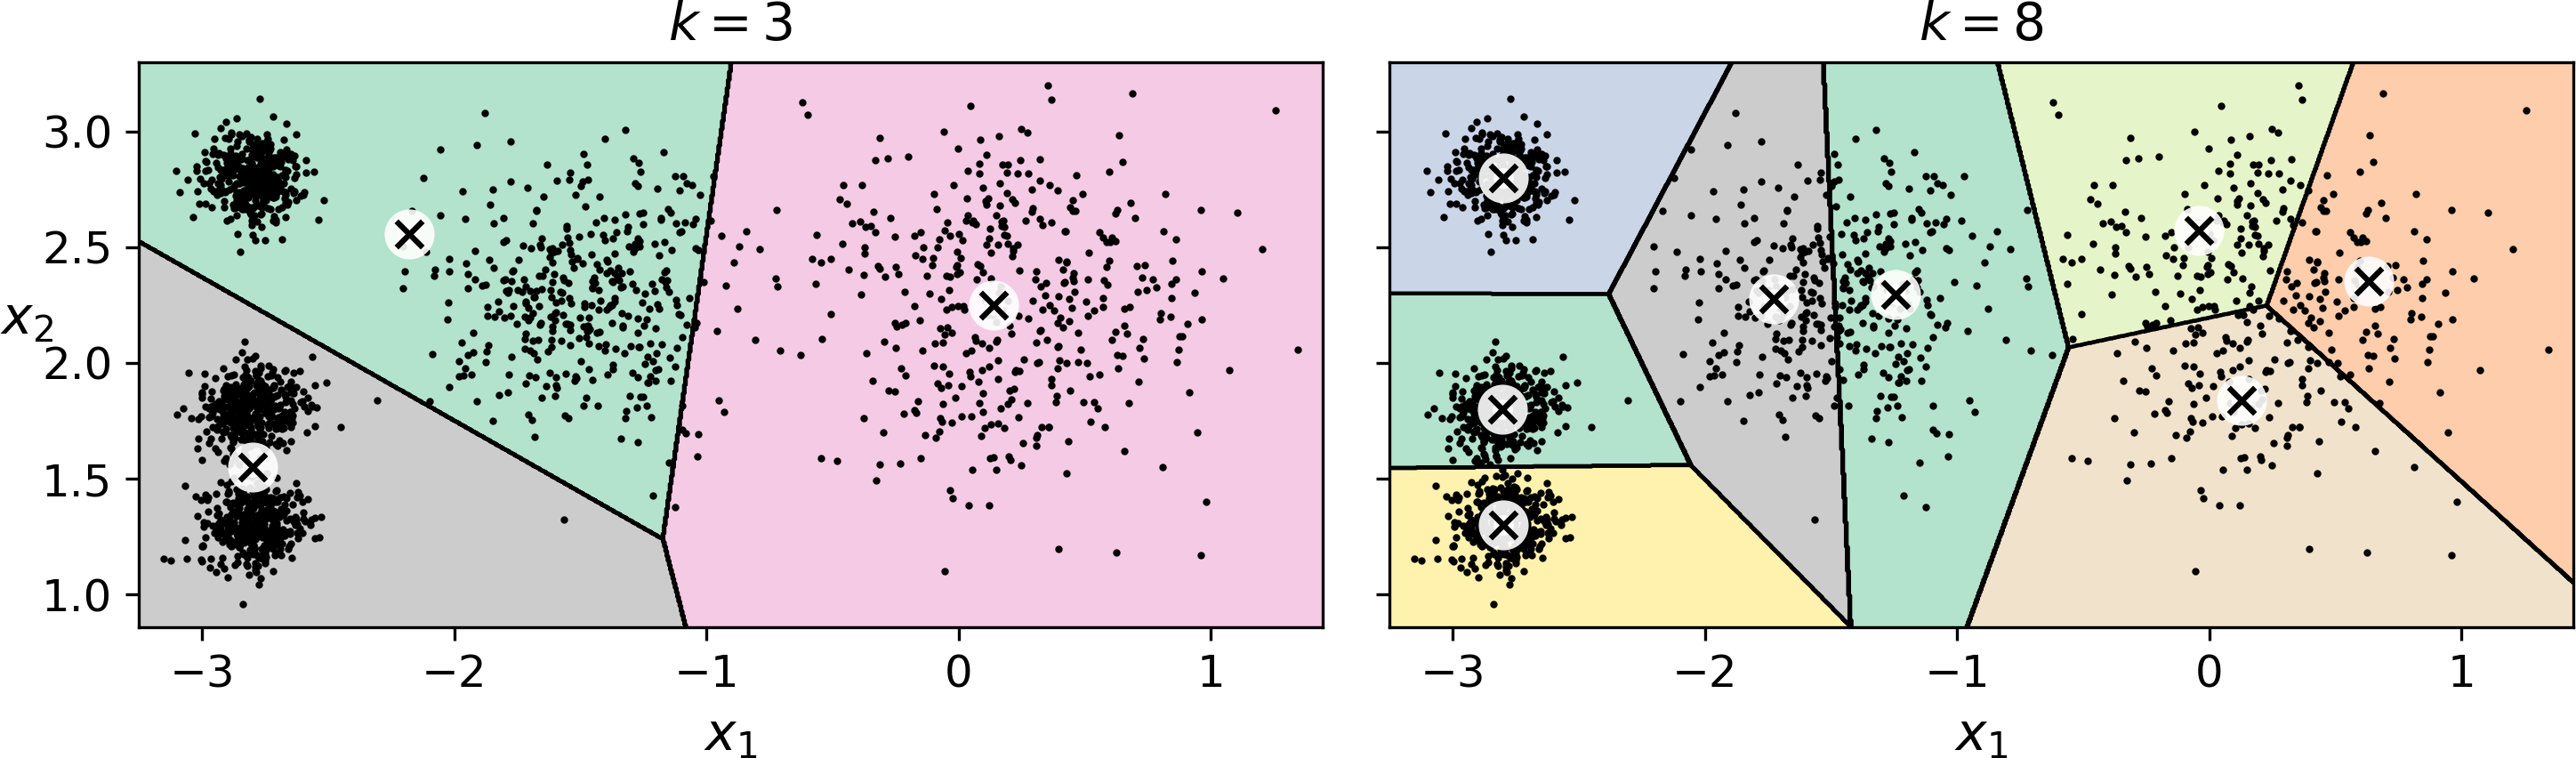
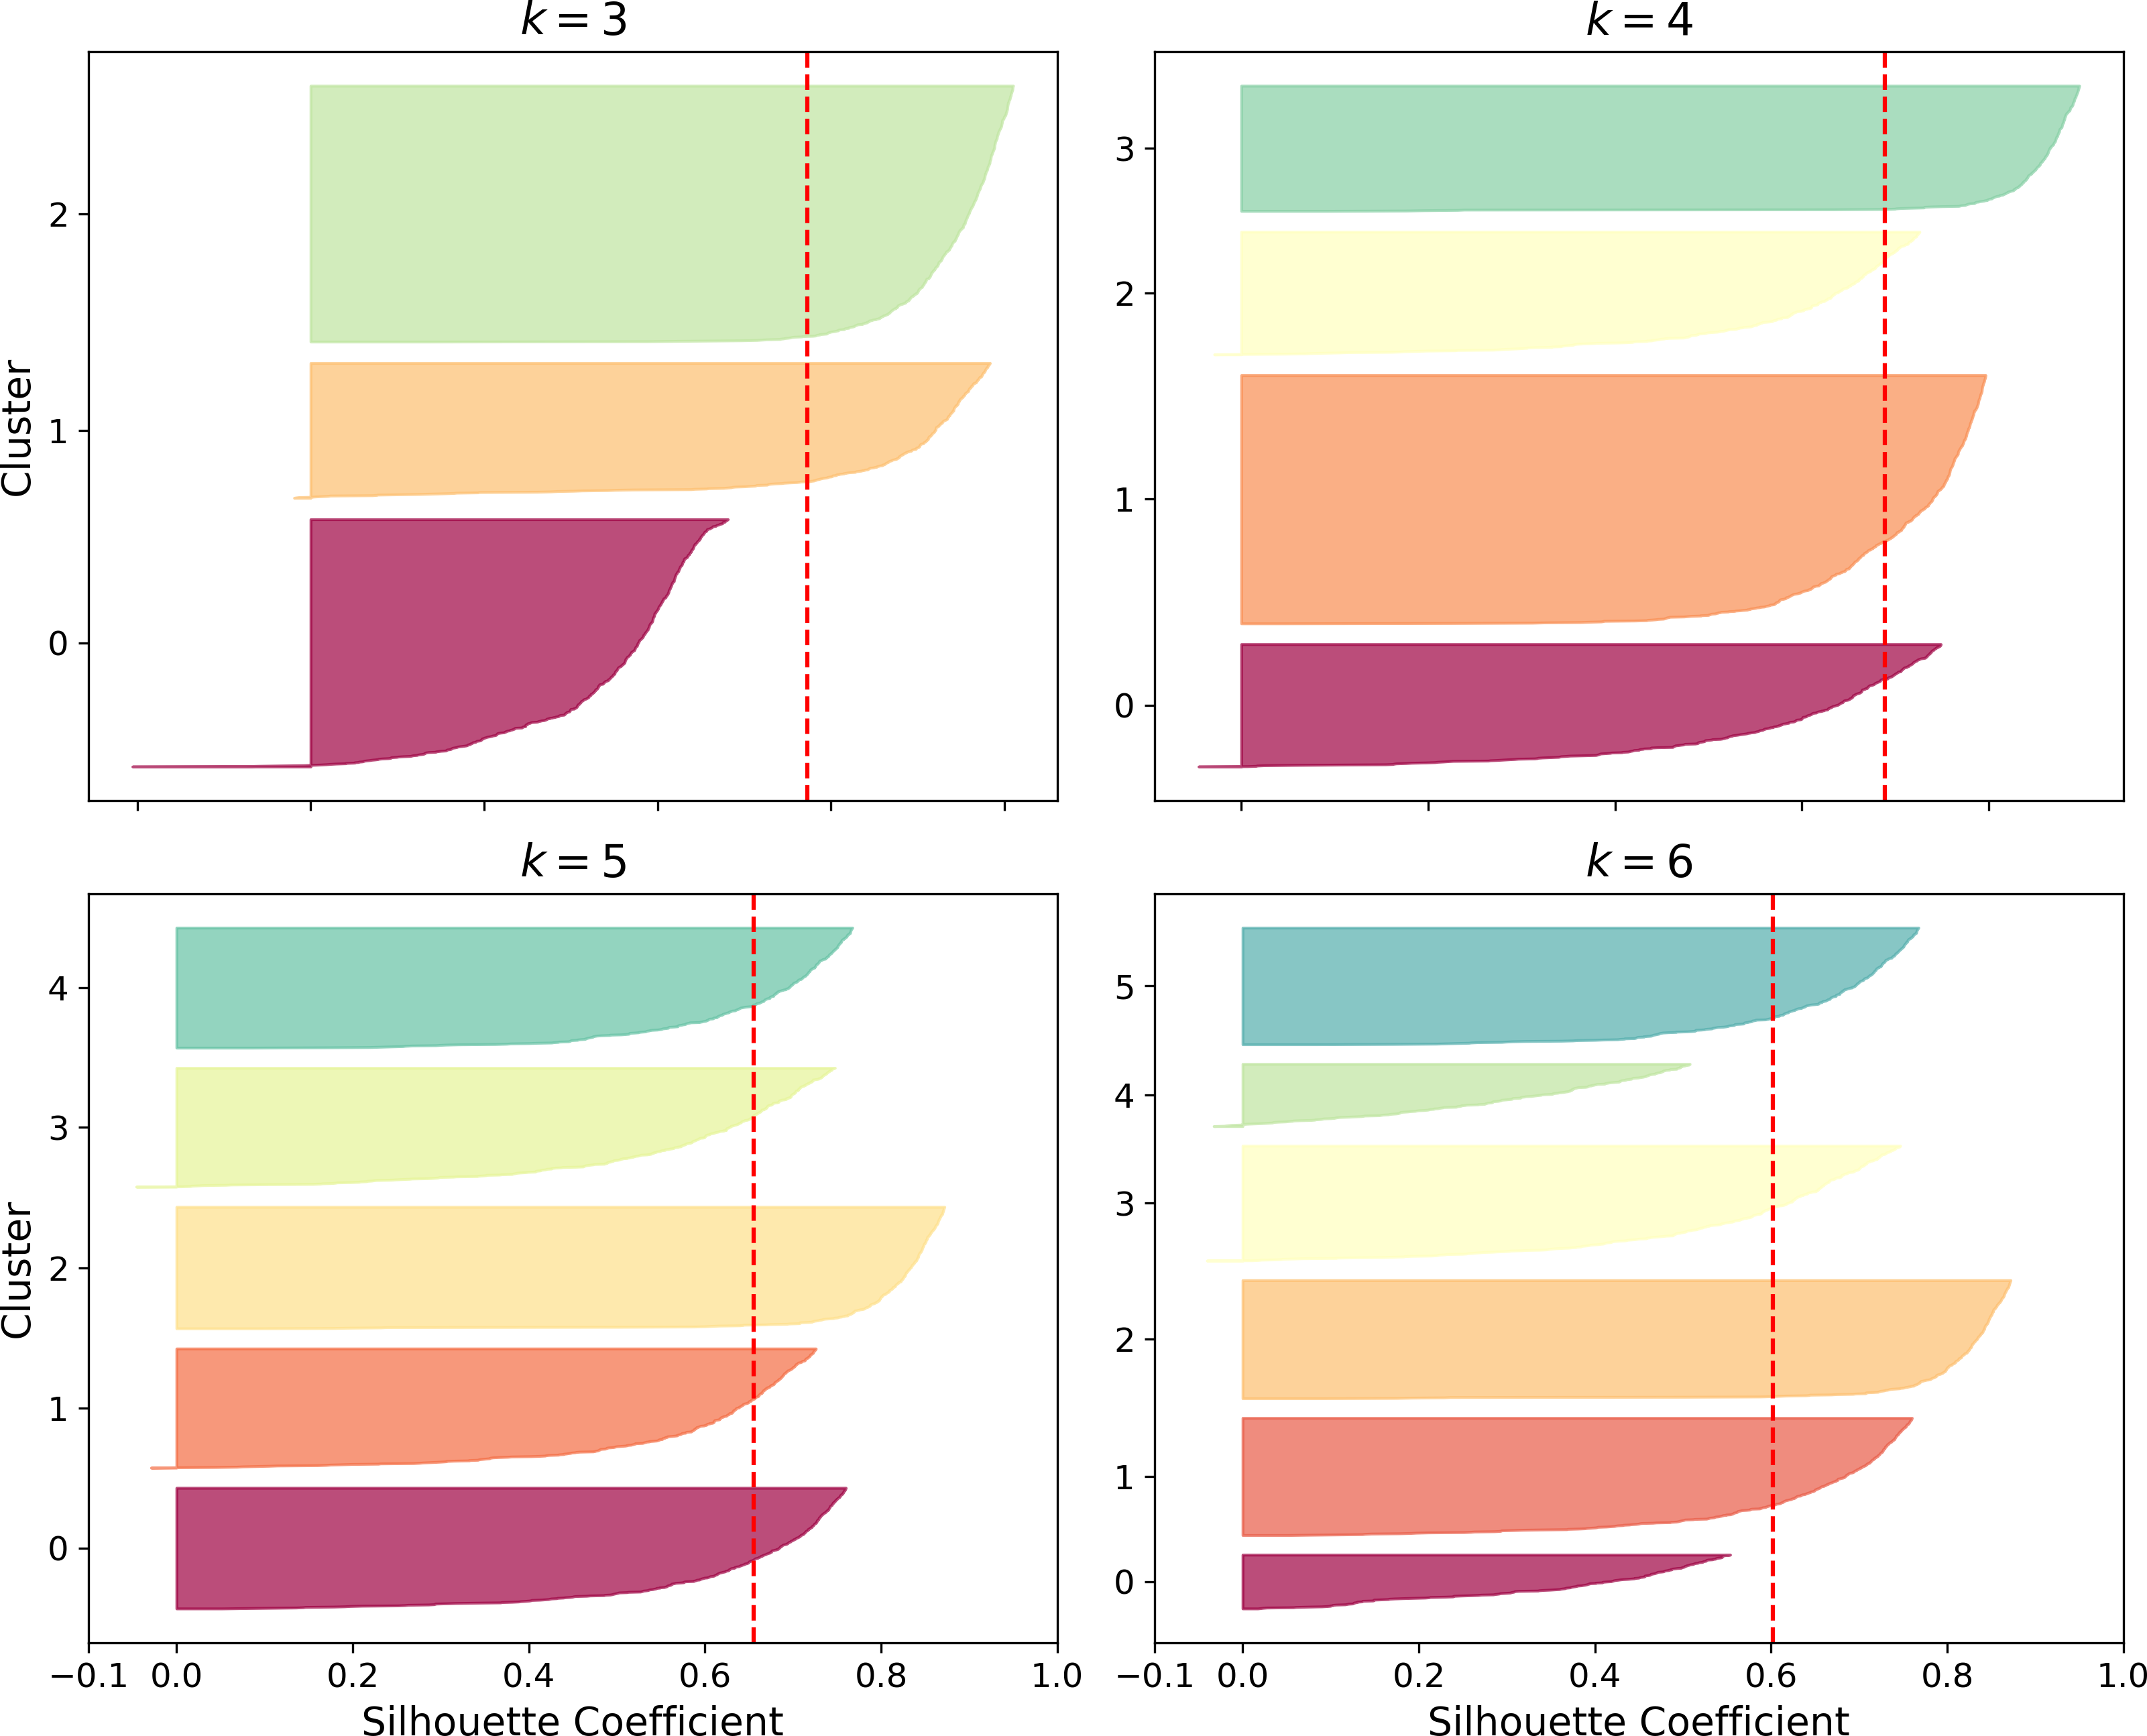
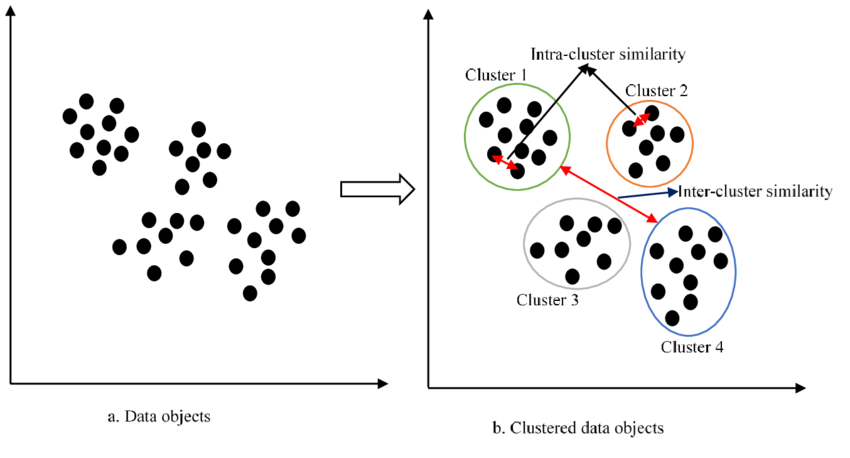
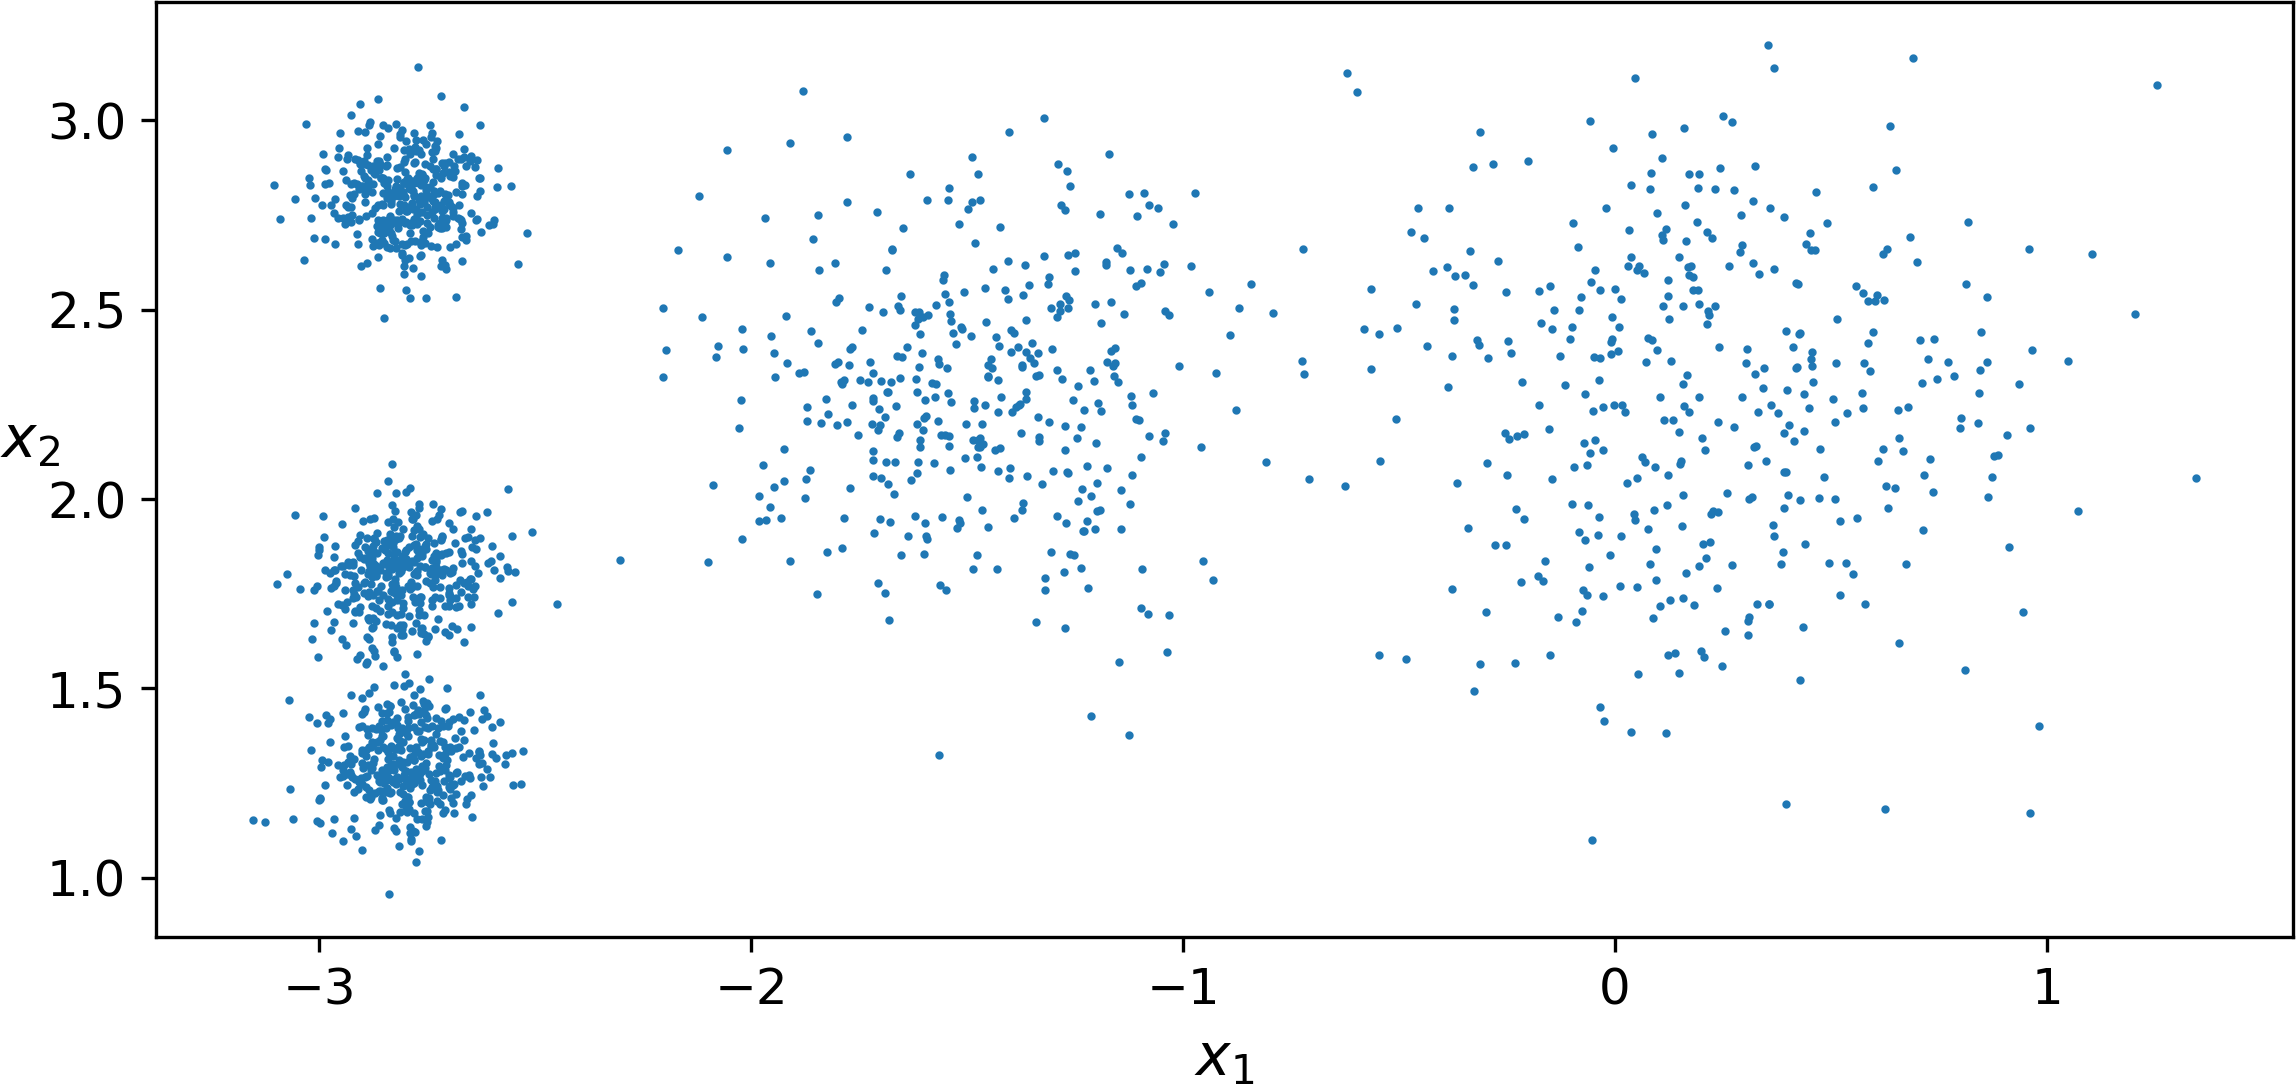

The following example employs the K-means clustering algorithm to partition the Iris dataset into three clusters. It's worth noting that while we haven't standardized the features in this instance, it's generally recommended to **standardize features** to ensure consistent scaling, which is crucial for K-means clustering. Additionally, it's important to acknowledge that the assigned cluster labels may not correspond directly to the original labels in the Iris dataset, as **K-means assigns cluster values randomly**. From the number of clusters and silhouette scores analysis, we get that the **optimal number of clusters** for this dataset is when $K$ = 2.

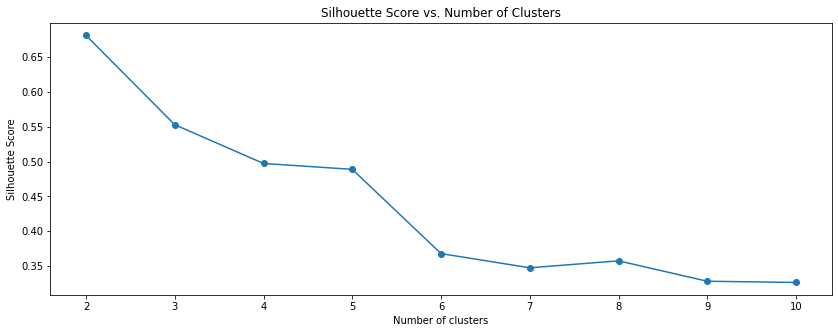

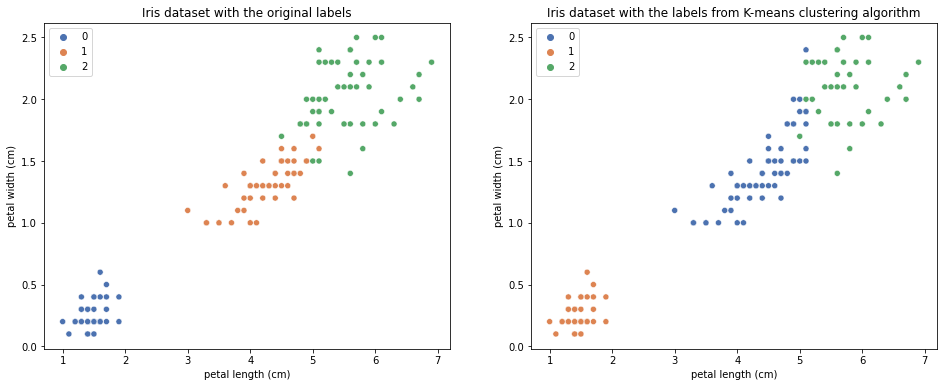

In [1]:
# If you get "NoneType' object has no attribute 'split" error, 
# use `pip install --upgrade threadpoolctl` to upgrade threadpoolctl.

# If you get a warning message "UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there 
# are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2",
# use the following two lines of code to suppress the warning.

import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target # Target (not used for clustering) - only used for comparision purposes

# evaluate clustering quality for different K values 
silhouette_scores = []
for n_clusters in range(2, 11):
    clustering = KMeans(n_clusters=n_clusters).fit(X)
    labels = clustering.labels_
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax = plt.subplots(figsize=(14,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Plot the irsis dataset use the two dominant features: petal width and petal length
sns.scatterplot(ax = ax[0], x = X['petal length (cm)'], y = X['petal width (cm)'], hue=y, palette="deep")
ax[0].set_title('Iris dataset with the original labels')
ax[0].set_xlabel('petal length (cm)')
ax[0].set_ylabel('petal width (cm)')

sns.scatterplot(ax = ax[1], x = X['petal length (cm)'], y = X['petal width (cm)'], hue=clusters, palette="deep")
ax[1].set_title('Iris dataset with the labels from K-means clustering algorithm')
ax[1].set_xlabel('petal length (cm)')
ax[1].set_ylabel('petal width (cm)')
plt.show()


The code below creates a **silhouette diagram** with the help of the silhouette_score function from scikit-learn and matplotlib for visualization. The code below is taken from: 
https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

For n_clusters = 2 The average silhouette_score is : 0.7049787496083262
For n_clusters = 3 The average silhouette_score is : 0.5882004012129721
For n_clusters = 4 The average silhouette_score is : 0.6505186632729437
For n_clusters = 5 The average silhouette_score is : 0.5804620679044765
For n_clusters = 6 The average silhouette_score is : 0.4966479110816958


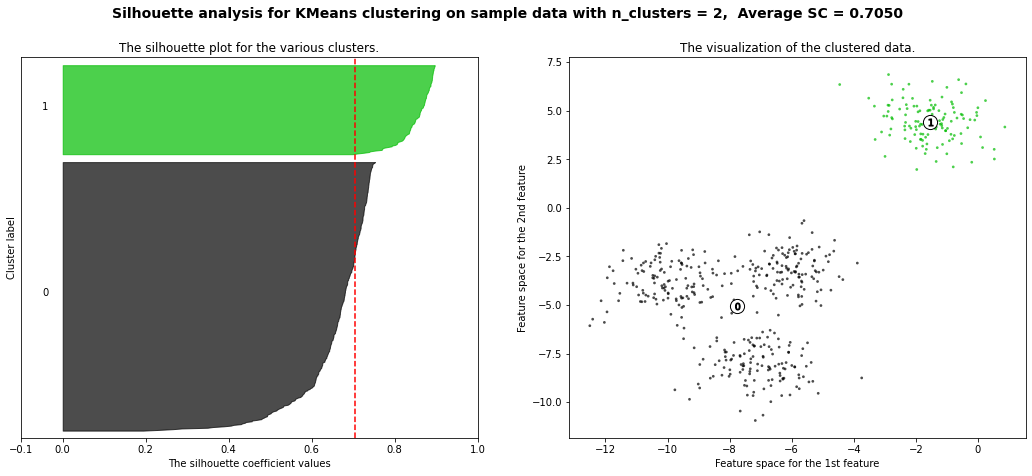

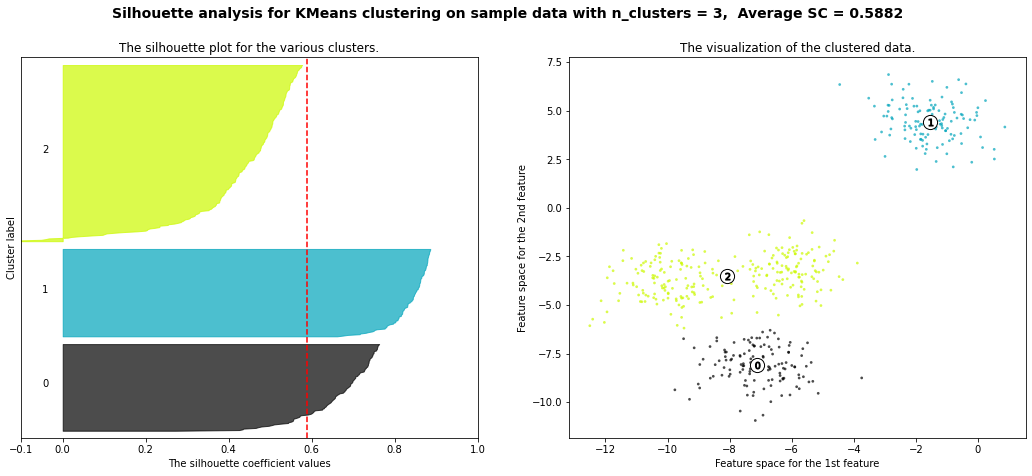

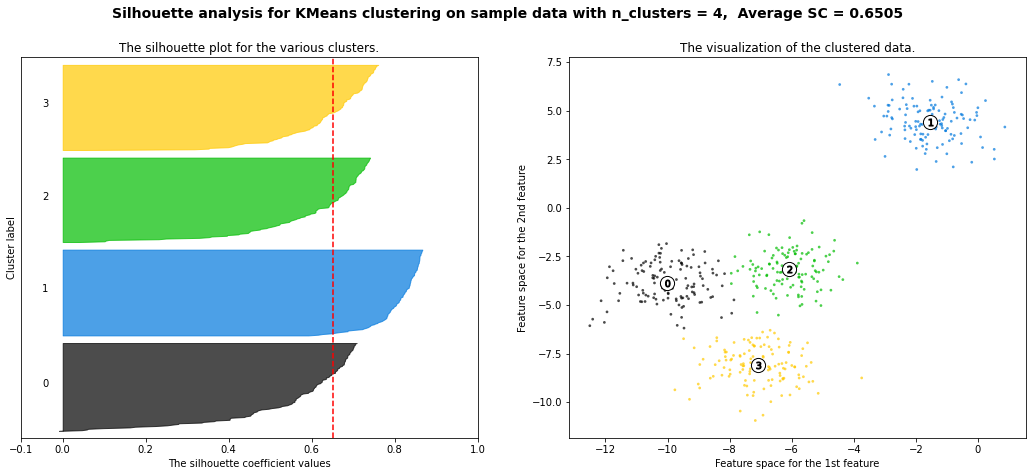

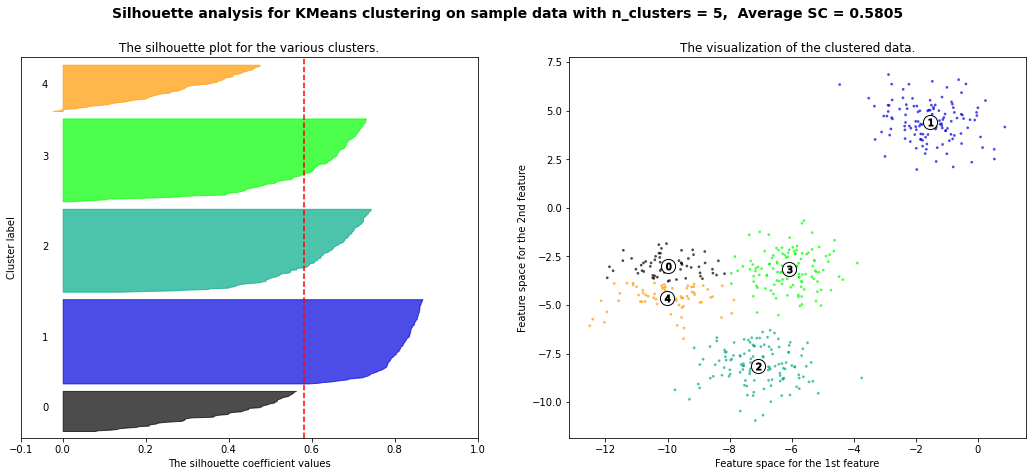

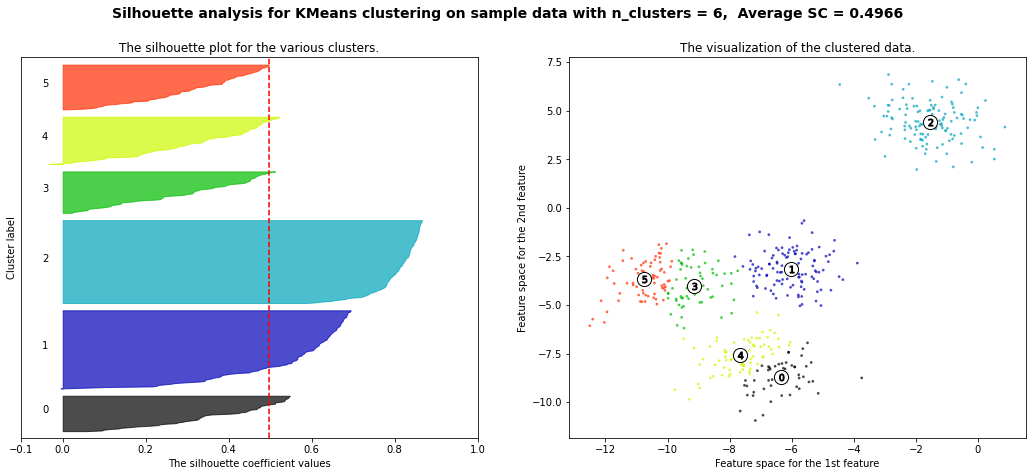

In [2]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=1,
)  # For reproducibility

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters},  Average SC = {silhouette_avg:.4f}",
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## Hierarchical Clustering

Hierarchical clustering is a method of clustering data that organizes observations into a hierarchy of clusters. Unlike K-means clustering, which requires specifying the number of clusters beforehand, hierarchical clustering does not require a predetermined number of clusters. Instead, it creates a tree-like structure, known as a dendrogram, that represents the relationships between data points.

There are two main types of hierarchical clustering:

1. **Agglomerative hierarchical clustering (Bottom-up approach)**: This method starts with each data point as a separate cluster and iteratively merges the closest pairs of clusters until only one cluster remains. The distance between clusters is determined using a specified distance metric, such as Euclidean distance or Manhattan distance. This process continues until all data points belong to a single cluster, forming a dendrogram.


2. **Divisive hierarchical clustering (Top-down approach)**: This method takes the opposite approach to agglomerative clustering. It starts with all data points in one cluster and recursively divides them into smaller clusters until each data point is in its own cluster. While divisive clustering can provide insights into the structure of the data, it is less commonly used compared to agglomerative clustering.

<br />
<div>
<img src=attachment:image.png width = 600>
</div>
<p style="text-align: center;"> <strong> Dendrogram plot</strong> </p>

*Image source: https://towardsdatascience.com/hierarchical-clustering-explained-e59b13846da8*

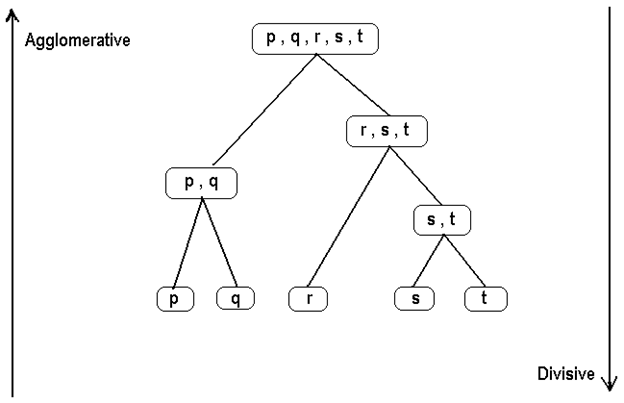

*Image source: https://www.solver.com/xlminer/help/hierarchical-clustering-intro*

The following example employs the agglomerative hierarchical clustering (bottom-up approach) clustering algorithm to partition the Iris dataset. In the code below, the `method='ward'` parameter specifies the method used to calculate the distance between newly formed clusters during the clustering process. Ward's method **merges** clusters that result in the **smallest increase** in **within-cluster** variance. For more information on linkage methods, visit: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html.    
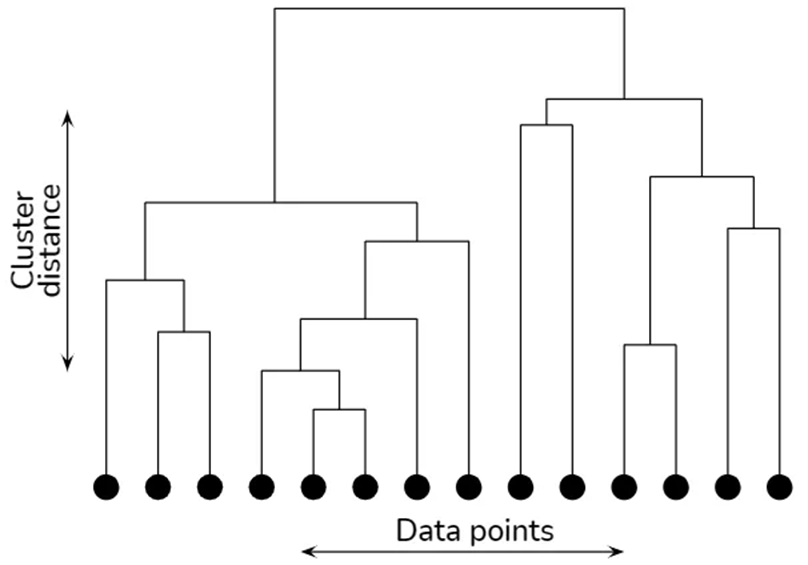

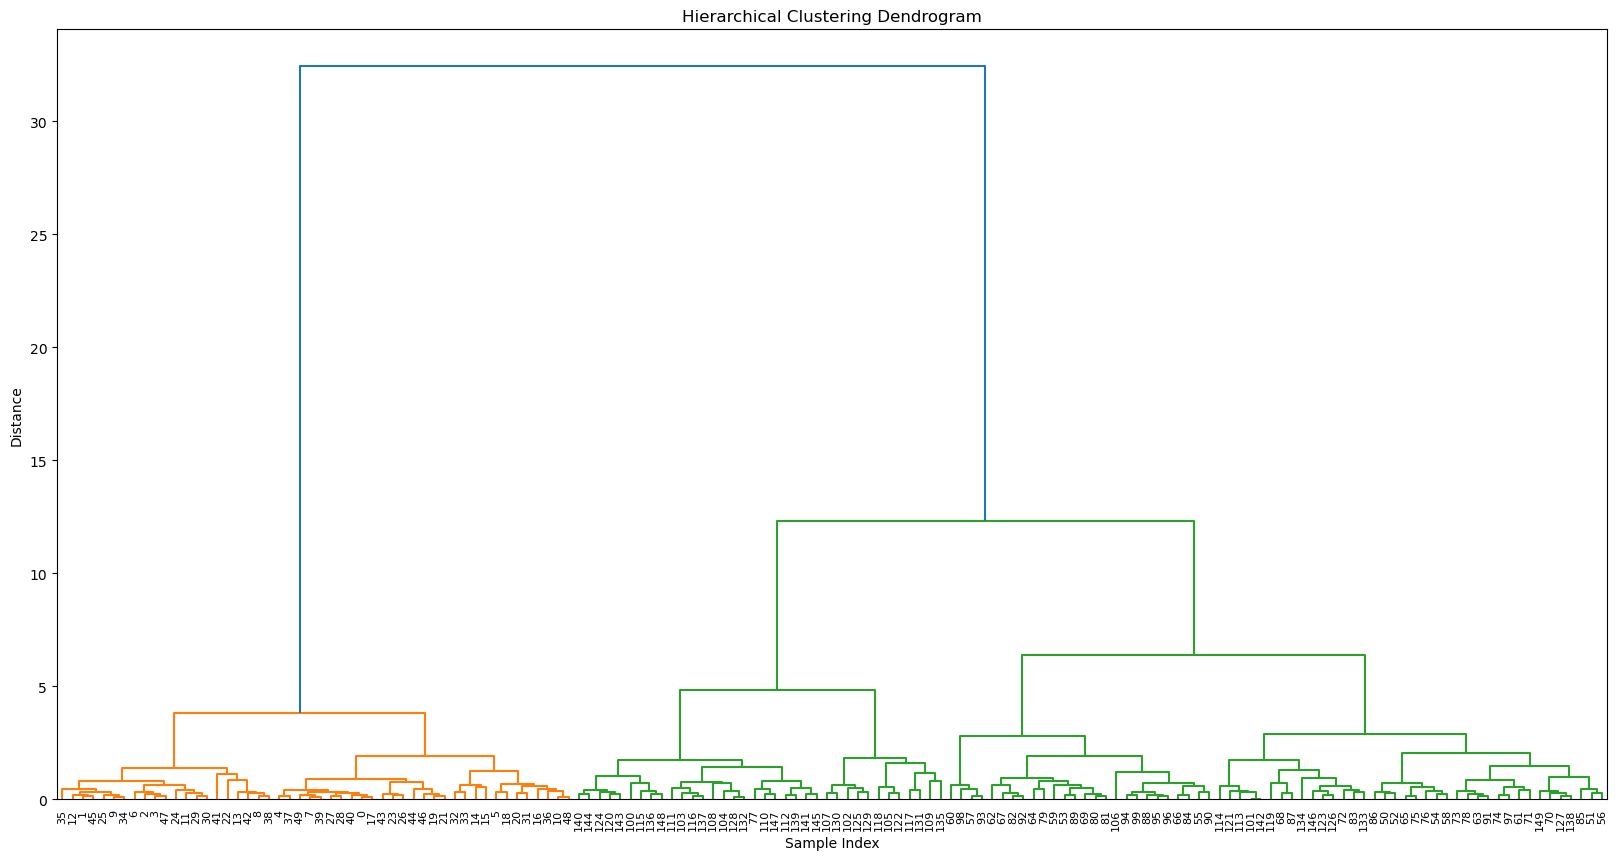

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Perform hierarchical clustering
h_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0)
clusters = h_clustering.fit_predict(X)

# Plot the dendrogram
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')


Z = linkage(X, method='ward')
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.show()

**Selecting a Distance Cut-Off (Determining the Number of Clusters)**

In Agglomerative Hierarchical Clustering, the `distance_threshold` parameter specifies the threshold for the **distance between clusters at which the algorithm will stop merging clusters and produce the final clusters**. Selecting an appropriate `distance_threshold` is crucial as it determines the granularity of the clustering solution.

Here's a step-by-step process for selecting the distance_threshold in agglomerative clustering after plotting dendrogram:

* **Understand the Data**: Before selecting the distance_threshold, it's essential to understand the characteristics of your data and the clustering task at hand. Consider factors such as the number of observations, dimensionality, and the presence of noise or outliers.


* **Identify Clusters**: Look for **horizontal lines** in the dendrogram, which represent individual data points or clusters. As you move up the dendrogram, these clusters merge into larger clusters.


* **Look for Significant Changes**: Identify significant changes in the dendrogram, where the distance between clusters increases abruptly. These changes indicate the formation of distinct clusters.


* **Select the distance_threshold**: Choose a distance_threshold that corresponds to the height of the dendrogram where significant changes occur. This threshold determines the level at which clusters are formed.

Based on the dendrogram plot above, notable changes occur around distances of 10 and 15. At a distance threshold of 15, the clustering yields two clusters, while at a threshold of 10, it results in three clusters.


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


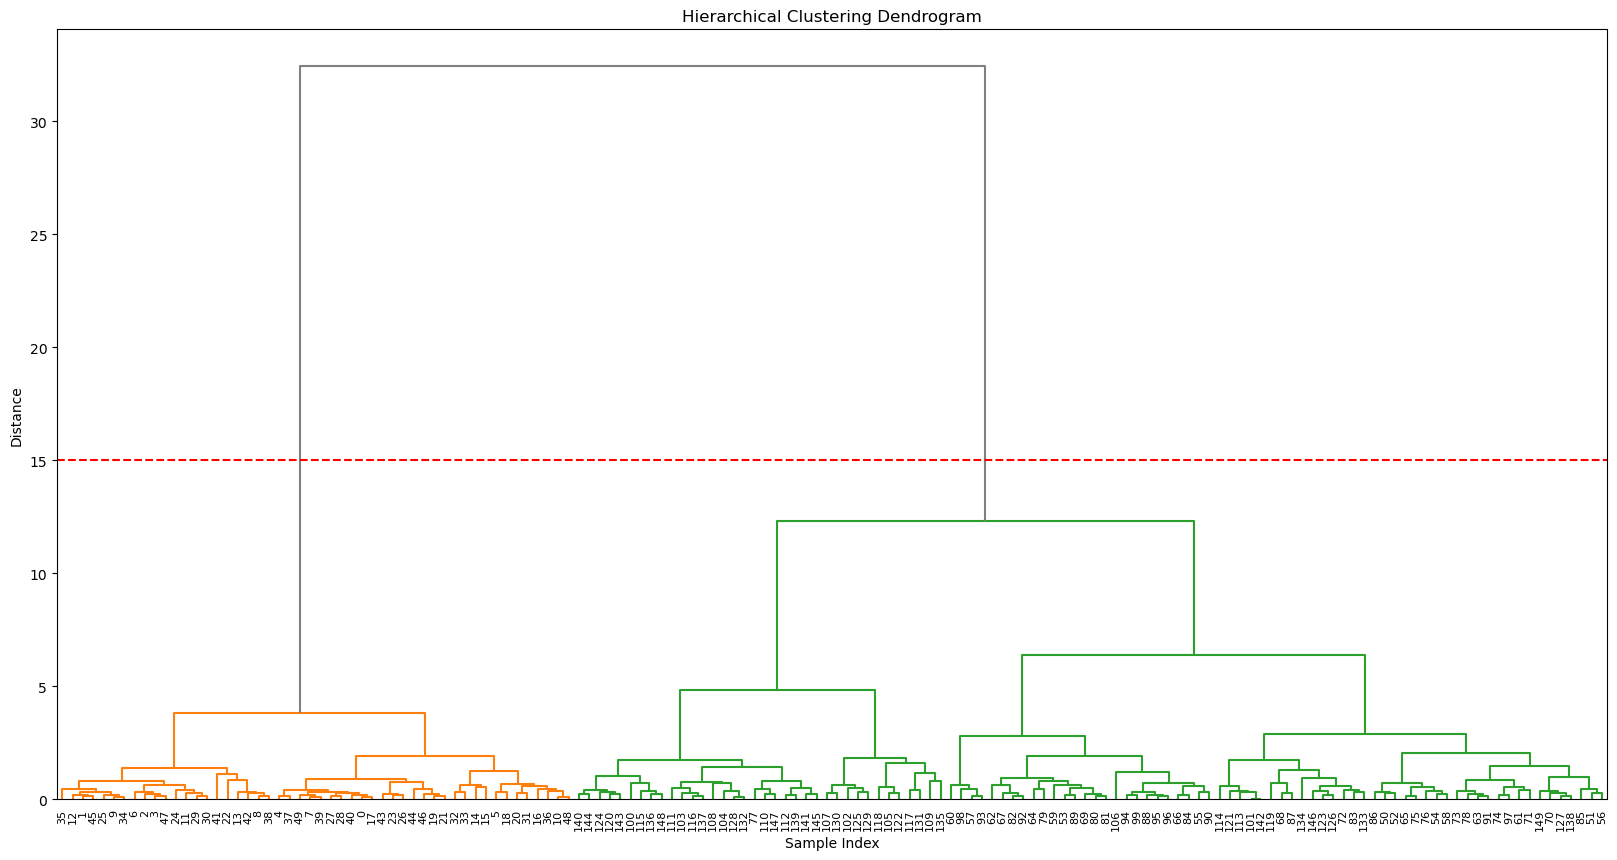

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Perform hierarchical clustering
h_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=15)
clusters = h_clustering.fit_predict(X)
print(clusters)

# Plot the dendrogram
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

Z = linkage(X, method='ward')
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    above_threshold_color='grey',  # color for clusters above the threshold
    color_threshold=15,  # set color threshold
)
plt.axhline(y=15, color='r', linestyle='--') # Plot a horizontal line at distance threshold
plt.show()

In dendrogram plotting, the `truncate_mode` parameter determines how the dendrogram is truncated when the **number of leaves exceeds a certain threshold**. This parameter is typically used to improve the visualization of the dendrogram when **dealing with large datasets** or when the dendrogram is too cluttered to be easily interpreted. The following code shows the last six merged clusters.

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


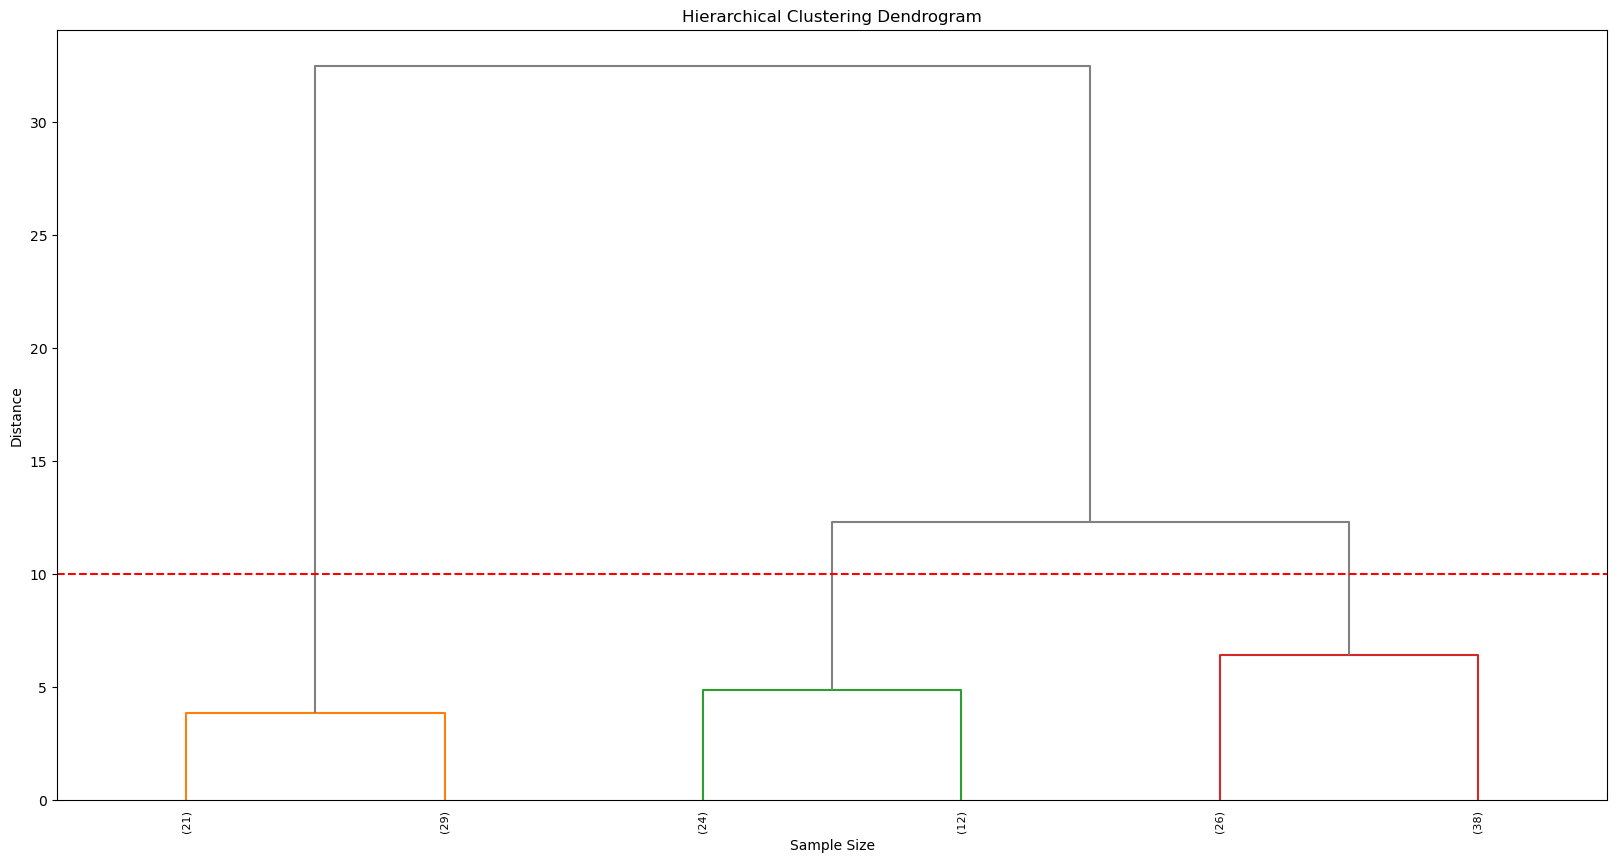

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Perform hierarchical clustering
h_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=10)
clusters = h_clustering.fit_predict(X)
print(clusters)

# Plot the dendrogram
plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Size')
plt.ylabel('Distance')

Z = linkage(X, method='ward')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=6,  # show only the last p merged clusters
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    above_threshold_color='grey',  # color for clusters above the threshold
    color_threshold=10,  # set color threshold
)
plt.axhline(y=10, color='r', linestyle='--') # Plot a horizontal line at distance threshold
plt.show()

The code below experiment with different values of n_clusters and silhouette scores, to find the **optimal cluster size** when using the agglomerative clustering. For the Iris dataset the optimal cluster size is when $K$ = 2.

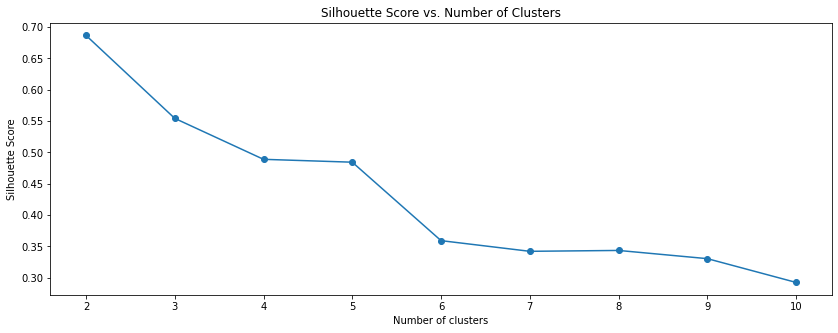

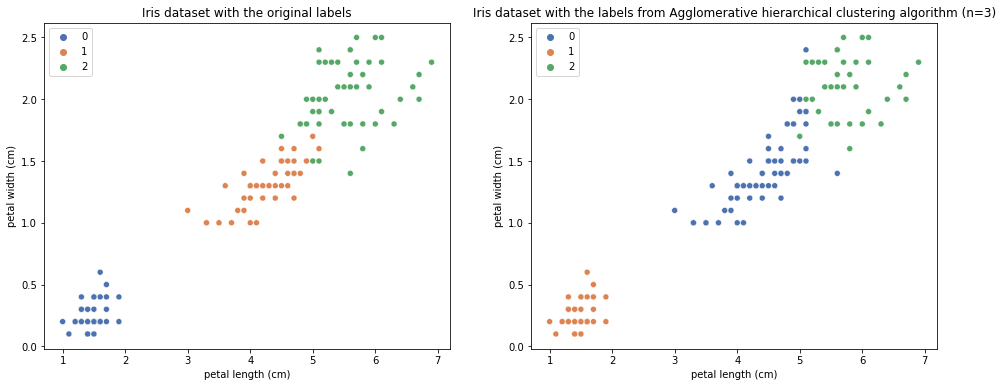

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Iris dataset
iris = load_iris()

X = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target # Target (not used for clustering) - only used for comparision purposes

# evaluate clustering quality for different number of clusters 
silhouette_scores = []
for n_clusters in range(2, 11):
    clustering = AgglomerativeClustering(n_clusters=n_clusters).fit(X)
    labels = clustering.labels_
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax = plt.subplots(figsize=(14,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()

# Perform hierarchical clustering
h_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=10)
clusters = h_clustering.fit_predict(X)

fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Plot the irsis dataset use the two dominant features: petal width and petal length
sns.scatterplot(ax = ax[0], x = X['petal length (cm)'], y = X['petal width (cm)'], hue=y, palette="deep")
ax[0].set_title('Iris dataset with the original labels')
ax[0].set_xlabel('petal length (cm)')
ax[0].set_ylabel('petal width (cm)')

sns.scatterplot(ax = ax[1], x = X['petal length (cm)'], y = X['petal width (cm)'], hue=clusters, palette="deep")
ax[1].set_title('Iris dataset with the labels from Agglomerative hierarchical clustering algorithm (n=3)')
ax[1].set_xlabel('petal length (cm)')
ax[1].set_ylabel('petal width (cm)')
plt.show()

**Other Clustering Algorithms Available in Scikit-learn Package**

Although we have only covered two clustering algorithms, there are several clustering algorithms available for different types of data and clustering tasks. Here's a list of some commonly used clustering methods in scikit-learn:

* **K-Means**: A centroid-based clustering algorithm that partitions data into K clusters by iteratively updating cluster centroids to minimize the within-cluster sum of squares.


* **Agglomerative Clustering**: A hierarchical clustering algorithm that recursively merges clusters based on the distance between them until only one cluster remains.


* **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**: A density-based clustering algorithm that groups together closely packed points based on a specified minimum number of points within a given distance.


* **OPTICS (Ordering Points To Identify the Clustering Structure)**: An extension of DBSCAN that generates a reachability plot to reveal the clustering structure and allows for clustering with varying densities.


* **Birch (Balanced Iterative Reducing and Clustering using Hierarchies)**: An efficient hierarchical clustering algorithm that uses a tree-based data structure to cluster large datasets.


* **Mean Shift**: A density-based clustering algorithm that identifies clusters as regions where the density of data points is highest.


* **Affinity Propagation**: A graph-based clustering algorithm that identifies "exemplar" data points and assigns other points to the nearest exemplar based on similarity.


* **Spectral Clustering**: A graph-based clustering algorithm that uses spectral graph theory to identify clusters based on the eigenvectors of a similarity matrix.


* **Agglomerative Hierarchical Clustering**: Available through `scipy.cluster.hierarchy`, this algorithm constructs a dendrogram to represent the hierarchical clustering structure.


* **Gaussian Mixture Models (GMM)**: A probabilistic clustering algorithm that models clusters as Gaussian distributions and assigns data points to clusters based on their likelihood under each distribution.

For more information on clustering algorithms available in the `scikit_learn` package, visit: https://scikit-learn.org/stable/modules/clustering.html.  

## Exercise (Image Clustering with Handwritten Digits Dataset)

In this exercise, you will perform image clustering using **K-means** and **Agglomerative Clustering** algorithms on the "Digits" dataset, which contains images of handwritten digits (0 through 9). Your goal is to cluster similar digits together based on their pixel intensities. Here are some key characteristics of the load_digits dataset:

* **Size**: The dataset contains 1,797 samples, each representing a handwritten digit.


* **Features**: Each sample consists of 64 features, representing the grayscale intensity of each pixel in the 8x8 image.


* **Target**: The dataset includes corresponding target values, indicating the actual digit (0 through 9) represented by each image.

**Tasks**

* Load the handwritten digits dataset (`from sklearn.datasets import load_digits`).


* Preprocess the data if necessary.


* Experiment with different values of n_clusters and silhouette scores for K-means and Agglomerative Clustering. What is the optimal number of clusters? 


* For the agglomerative clustering, plot the dendrogram plot and identify significant changes in the dendrogram, where the distance between clusters increases abruptly.

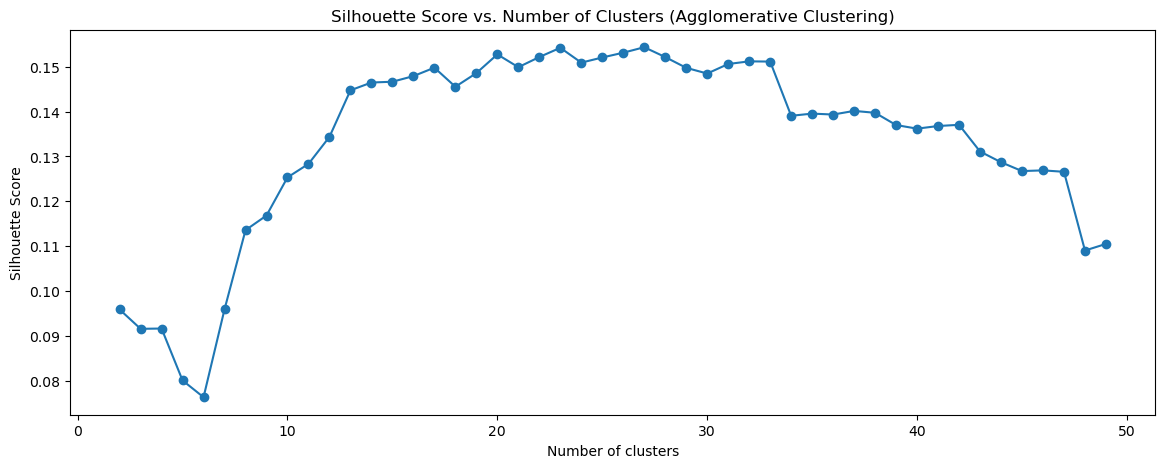

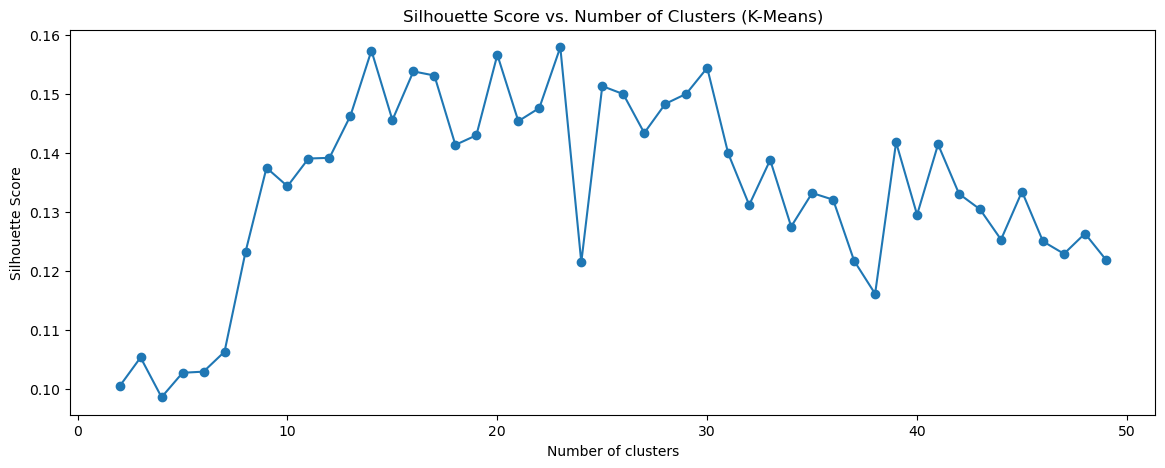

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data

scaler = StandardScaler()
X = scaler.fit_transform(X)

# evaluate clustering quality for different number of clusters (AgglomerativeClustering)
silhouette_scores = []
for n_clusters in range(2, 50):
    clustering = AgglomerativeClustering(n_clusters=n_clusters).fit(X)
    labels = clustering.labels_
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax = plt.subplots(figsize=(14,5))
plt.plot(range(2, 50), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (Agglomerative Clustering)')
plt.show()


# evaluate clustering quality for different number of clusters (Kmeans) 
silhouette_scores = []
for n_clusters in range(2, 50):
    clustering = KMeans(n_clusters=n_clusters).fit(X)
    labels = clustering.labels_
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax = plt.subplots(figsize=(14,5))
plt.plot(range(2, 50), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (K-Means)')
plt.show()


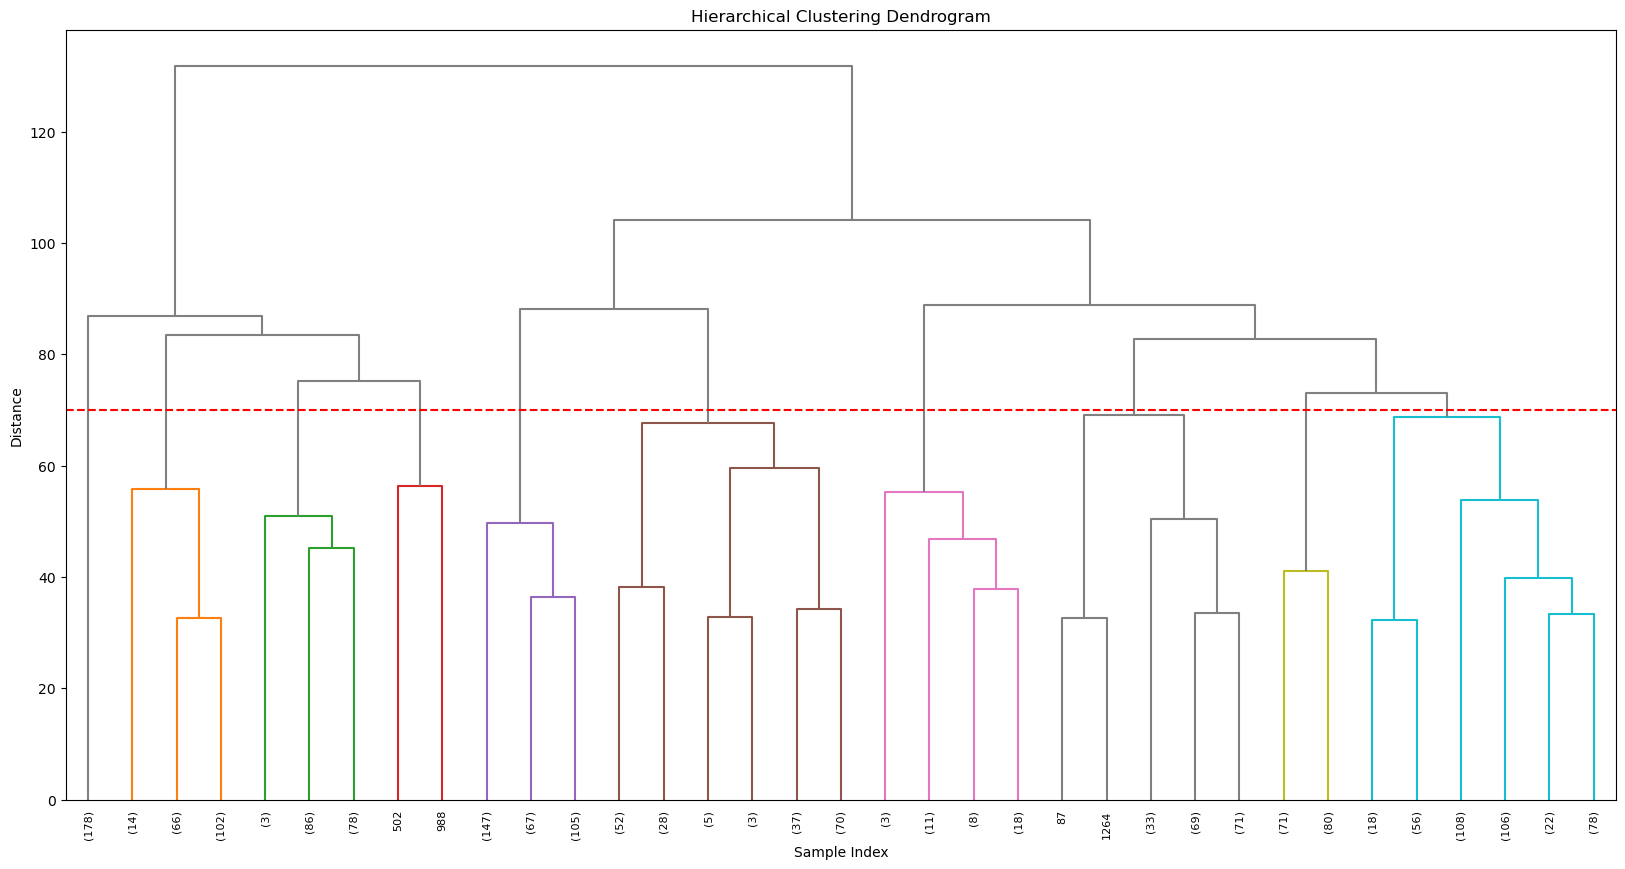

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

Z = linkage(X, method='ward')
dendrogram(
    Z,
    truncate_mode='lastp', 
    p=35, 
    leaf_rotation=90., 
    leaf_font_size=8.,  
    above_threshold_color='grey',  
    color_threshold=70, 
)
plt.axhline(y=70, color='r', linestyle='--') # Plot a horizontal line at distance threshold
plt.show()